# Tutorial 5: Inference Methods — Adam, NUTS, and geoVI

This notebook compares three inference backends on the same mock galaxy:
1. **MAP via Adam** (optax) — fast point estimate, always available
2. **NUTS via BlackJAX** — gold-standard MCMC posteriors (requires `blackjax`)
3. **geoVI via NIFTy.re** — fast variational inference (requires `nifty8.re`)

Each has different trade-offs in speed, posterior quality, and scalability.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, "../src")

from diffsed.utils.devices import setup_jax
setup_jax()

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
    "axes.linewidth": 1.0, "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True, "legend.framealpha": 0.9})

from diffsed.models.sps.dsps_wrapper import load_ssp_data
from diffsed.forward_model import ForwardModel, ModelConfig, generate_mock
from diffsed.inference.map_optimizer import fit_map
from diffsed.models.sfh.gp_sfh import gp_from_xi, compute_sqrt_power_drw
from diffsed.models.sfh.psd_models import drw_variance
from diffsed.models.sfh.mean_sfh import double_powerlaw
from diffsed.utils.grid import make_log_age_grid, grid_spacing, log_age_to_age_yr

ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# Setup
N_GRID = 256
filter_centers = [3551, 4686, 6166, 7480, 8932]
half_w = 100.0
filter_waves = [jnp.linspace(c - half_w, c + half_w, 50) for c in filter_centers]
filter_trans = [jnp.ones(50) for _ in filter_centers]

log_age_grid = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_age_grid)
age_yr = log_age_to_age_yr(log_age_grid)
age_gyr = age_yr / 1e9

config = ModelConfig(n_grid=N_GRID, redshift=0.1)
model = ForwardModel(ssp_data, config, filter_waves, filter_trans)

# True galaxy
true_params = {
    "xi": jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,)),
    "sigma_ps": 1.5, "tau_ps": 30e6,
    "alpha": 1.5, "beta": 0.8, "tau_sfh": 2e9, "sfr_norm": 5.0,
    "log_z": -0.5, "tau_v1": 1.0, "tau_v2": 0.3, "dust_n": -0.7,
}
mock = generate_mock(model, true_params, key=jax.random.PRNGKey(0), snr=20.0)

# True SFH
def compute_sfh(p):
    sp = compute_sqrt_power_drw(N_GRID, float(d_log_age), p["sigma_ps"], p["tau_ps"])
    gx = gp_from_xi(p["xi"], sp, N_GRID)
    k0 = drw_variance(p["sigma_ps"]) / 2.0
    sm = double_powerlaw(age_yr, p["alpha"], p["beta"], p["tau_sfh"], p["sfr_norm"])
    return sm * jnp.exp(gx - k0)

sfr_true = compute_sfh(true_params)
print("Mock galaxy generated (5-band photometry, SNR=20).")

W0313 16:29:37.822249 2167463 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Mock galaxy generated (5-band photometry, SNR=20).


---
## Method 1: MAP via Adam (always available)

Gradient descent to find the maximum a posteriori point estimate. Fast but gives **no uncertainties**.

  Step     0/2000: loss = 15383.9595


  Step   200/2000: loss = 567.4859


  Step   400/2000: loss = 174.9352


  Step   600/2000: loss = 137.3046


  Step   800/2000: loss = 118.2554


...

  Step  1200/2000: loss = 92.4563


  Step  1400/2000: loss = 81.0007


  Step  1600/2000: loss = 69.6578


  Step  1800/2000: loss = 59.3012


  Step  1999/2000: loss = 50.8043
  MAP optimization complete in 4.1s


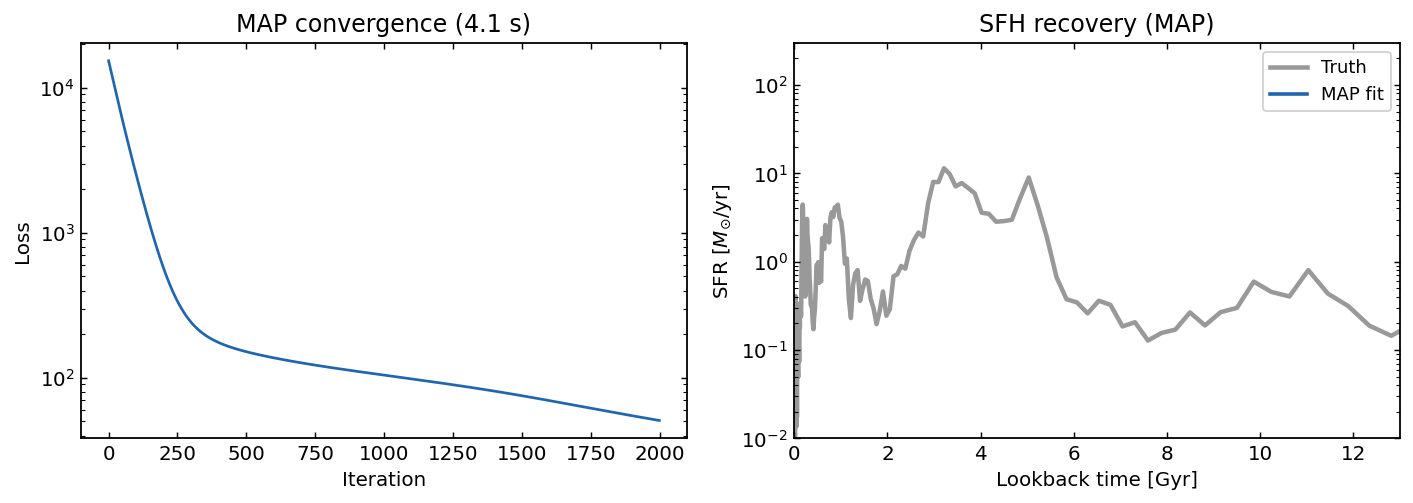

MAP: 4.1 s, final loss = 50.80
Pros: Fast, always available. Cons: No uncertainties.


In [2]:
result_map = fit_map(
    model, mock["flux_obs"], mock["noise"],
    key=jax.random.PRNGKey(10),
    n_steps=2000, learning_rate=0.01,
    data_type="photometry",
)

sfr_map = compute_sfh(result_map.params)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(result_map.loss_history, color="#2166ac", lw=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title(f"MAP convergence ({result_map.wall_time_s:.1f} s)")
ax.set_yscale("log")

ax = axes[1]
ax.plot(age_gyr, sfr_true, "k-", lw=2.5, alpha=0.4, label="Truth")
ax.plot(age_gyr, sfr_map, color="#2166ac", lw=2, label="MAP fit")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel(r"SFR [$M_{\odot}$/yr]")
ax.set_title("SFH recovery (MAP)")
ax.set_xlim(0, 13)
ax.set_yscale("log")
ax.set_ylim(0.01, 300)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("figures/05_map_result.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"MAP: {result_map.wall_time_s:.1f} s, final loss = {float(result_map.loss_history[-1]):.2f}")
print("Pros: Fast, always available. Cons: No uncertainties.")

---
## Method 2: NUTS via BlackJAX

No-U-Turn Sampler — the gold standard for posterior sampling. Requires `blackjax`.

In [3]:
try:
    from diffsed.inference.nuts import fit_nuts
    
    result_nuts = fit_nuts(
        model, mock["flux_obs"], mock["noise"],
        key=jax.random.PRNGKey(20),
        n_warmup=200, n_samples=300, n_chains=1,
        data_type="photometry",
    )
    
    has_nuts = True
    print(f"NUTS: {result_nuts.wall_time_s:.1f} s")
    print(f"  Samples: {result_nuts.diagnostics.get('n_samples', 'N/A')}")
    print(f"  Divergences: {result_nuts.diagnostics.get('n_divergences', 'N/A')}")
    
except ImportError:
    has_nuts = False
    print("BlackJAX not installed. Install with: pip install blackjax")
    print("Skipping NUTS section.")
except Exception as e:
    has_nuts = False
    print(f"NUTS failed: {e}")
    print("This can happen if the posterior geometry is difficult.")

BlackJAX not installed. Install with: pip install blackjax
Skipping NUTS section.


In [4]:
if has_nuts and result_nuts.samples is not None:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    
    n_show = min(50, len(result_nuts.samples.get("xi", [])))
    if n_show > 0 and "xi" in result_nuts.samples:
        for i in range(n_show):
            sample_params = {k: v[i] if hasattr(v, '__getitem__') and v.ndim > 0 
                            else v for k, v in result_nuts.samples.items()}
            try:
                sfr_i = compute_sfh(sample_params)
                ax.plot(age_gyr, sfr_i, alpha=0.1, lw=0.5, color="#ef8a62")
            except Exception:
                pass
    
    ax.plot(age_gyr, sfr_true, "k-", lw=2.5, alpha=0.5, label="Truth")
    ax.plot(age_gyr, sfr_map, color="#2166ac", lw=2, ls="--", alpha=0.5, label="MAP")
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_{\odot}$/yr]")
    ax.set_title(f"NUTS posterior SFH samples ({result_nuts.wall_time_s:.1f} s)")
    ax.set_xlim(0, 13)
    ax.set_yscale("log")
    ax.set_ylim(0.01, 300)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig("figures/05_nuts_posterior.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("NUTS results not available — skipping posterior plot.")

NUTS results not available — skipping posterior plot.


---
## Method 3: geoVI via NIFTy.re

Geometric Variational Inference — fast approximate posteriors. Requires `nifty8.re`.

In [5]:
try:
    from diffsed.inference.geovi import fit_geovi
    
    result_geovi = fit_geovi(
        model, mock["flux_obs"], mock["noise"],
        key=jax.random.PRNGKey(30),
        n_iterations=6, n_samples=4,
        data_type="photometry",
    )
    
    has_geovi = True
    print(f"geoVI: {result_geovi.wall_time_s:.1f} s, {result_geovi.diagnostics.get('n_iterations', 'N/A')} iterations")

except ImportError:
    has_geovi = False
    print("NIFTy.re not installed. Install with: pip install nifty8[re]")
    print("Skipping geoVI section.")
except Exception as e:
    has_geovi = False
    print(f"geoVI failed: {e}")

NIFTy.re not installed. Install with: pip install nifty8[re]
Skipping geoVI section.


---
## Comparison

In [6]:
print("Method Comparison")
print("=" * 65)
print(f"{'Method':<15s} {'Time (s)':<12s} {'Uncertainties':<15s} {'Dependency':<15s}")
print("-" * 65)
print(f"{'MAP (Adam)':<15s} {result_map.wall_time_s:<12.1f} {'No':<15s} {'optax':<15s}")

if has_nuts:
    print(f"{'NUTS':<15s} {result_nuts.wall_time_s:<12.1f} {'Yes (MCMC)':<15s} {'blackjax':<15s}")
else:
    print(f"{'NUTS':<15s} {'N/A':<12s} {'Yes (MCMC)':<15s} {'blackjax':<15s}")

if has_geovi:
    print(f"{'geoVI':<15s} {result_geovi.wall_time_s:<12.1f} {'Yes (VI)':<15s} {'nifty8.re':<15s}")
else:
    print(f"{'geoVI':<15s} {'N/A':<12s} {'Yes (VI)':<15s} {'nifty8.re':<15s}")

print()
print("When to use each:")
print("  MAP:   Quick fits, large catalogs, initial guesses")
print("  NUTS:  Gold-standard posteriors, small samples, paper-quality results")
print("  geoVI: Fast approximate posteriors, medium catalogs, hierarchical models")

Method Comparison
Method          Time (s)     Uncertainties   Dependency     
-----------------------------------------------------------------
MAP (Adam)      4.1          No              optax          
NUTS            N/A          Yes (MCMC)      blackjax       
geoVI           N/A          Yes (VI)        nifty8.re      

When to use each:
  MAP:   Quick fits, large catalogs, initial guesses
  NUTS:  Gold-standard posteriors, small samples, paper-quality results
  geoVI: Fast approximate posteriors, medium catalogs, hierarchical models


---
## Summary

| Method | Speed | Uncertainties | Scalability | Best for |
|--------|-------|--------------|-------------|----------|
| **MAP (Adam)** | Seconds | No | Excellent | Large surveys, initial guesses |
| **NUTS (BlackJAX)** | Minutes | Yes (exact) | Limited | Gold-standard posteriors |
| **geoVI (NIFTy.re)** | Seconds | Yes (approx) | Good | Catalogs, hierarchical |

All three exploit the **end-to-end gradients** that make `diffsed` unique among SED fitting codes. Traditional codes like Prospector use gradient-free methods (dynesty, emcee) which are orders of magnitude slower.